# Лабораторная 1: декодерный трансформер для предсказания следующего токена

## Что нужно знать до старта
Перед началом лабораторной полезно открыть:
- [../README.md](./README.md)
- [guides/00_autoregression_prerequisites.md](./guides/00_autoregression_prerequisites.md)
- [guides/01_decoder_only_toy_walkthrough.md](./guides/01_decoder_only_toy_walkthrough.md)
- [../theory/theory.md](../theory/theory.md)

Это первая лабораторная блока `04-Autoregression` и Шаг 7 общего курса.


## Выбор среды выполнения

Рекомендуемый стартовый режим: `auto`.

Если нужна полностью воспроизводимая проверка на центральном процессоре, выберите `local-cpu` и выполните `Restart & Run All`.


In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

RUNTIME_MODE = os.environ.get("COURSE_RUNTIME_MODE", "auto")
COURSE_REPO_HTTPS_URL = os.environ.get(
    "COURSE_REPO_HTTPS_URL",
    "https://github.com/<org>/<repo>.git",
)
NOTEBOOK_REQUIREMENTS = "themes/04-Autoregression/lab/requirements.txt"


def _detect_notebook_platform():
    """Определяет тип среды выполнения текущей тетради.

    Аргументы:
      Нет.

    Возвращает:
      Строка из множества `{'local', 'colab', 'kaggle'}`.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle").exists():
        return "kaggle"
    if os.environ.get("COLAB_RELEASE_TAG") or "google.colab" in sys.modules:
        return "colab"
    return "local"


def _looks_like_repo_root(path: Path) -> bool:
    """Проверяет, похож ли путь на корень учебного репозитория.

    Аргументы:
      path: Проверяемый путь.

    Возвращает:
      `True`, если обнаружены ключевые признаки корня репозитория.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return (
        path.is_dir()
        and (path / "themes").is_dir()
        and (path / "course_runtime.py").is_file()
    )


def _canonical_cloud_repo_root(platform: str) -> Path:
    """Возвращает стандартный путь клонирования для облачной платформы.

    Аргументы:
      platform: Имя платформы (`'colab'` или `'kaggle'`).

    Возвращает:
      Абсолютный путь каталога репозитория.

    Исключения:
      ValueError: Если передано неподдерживаемое имя платформы.
    """
    if platform == "colab":
        return Path("/content/students-AI_math_essentials")
    if platform == "kaggle":
        return Path("/kaggle/working/students-AI_math_essentials")
    raise ValueError(f"Unexpected cloud platform: {platform}")


def _is_placeholder_repo_url(repo_url: str) -> bool:
    """Проверяет, остался ли в настройке шаблонный URL репозитория.

    Аргументы:
      repo_url: Проверяемый URL репозитория.

    Возвращает:
      `True`, если URL имеет вид шаблона-заглушки.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return repo_url.strip() == "https://github.com/<org>/<repo>.git"


def _find_repo_root_from_cwd():
    """Ищет корень курса, поднимаясь от текущего каталога вверх.

    Аргументы:
      Нет.

    Возвращает:
      Объект `Path` корня репозитория или `None`, если путь не найден.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if _looks_like_repo_root(candidate):
            return candidate
    return None


def _ensure_course_runtime_importable(runtime_mode: str, repo_url: str) -> None:
    """Обеспечивает доступность модуля `course_runtime` для текущей среды.

    Аргументы:
      runtime_mode: Режим запуска тетради.
      repo_url: URL репозитория курса для облачной автозагрузки.

    Возвращает:
      `None`.

    Исключения:
      ModuleNotFoundError: Если локальный запуск выполнен вне корректного корня репозитория.
      RuntimeError: Если в облаке отсутствует валидный URL репозитория или каталог повреждён.
      subprocess.CalledProcessError: Если команда `git clone` завершается с ошибкой.
    """
    if importlib.util.find_spec("course_runtime") is not None:
        return

    local_repo_root = _find_repo_root_from_cwd()
    if local_repo_root is not None:
        if str(local_repo_root) not in sys.path:
            sys.path.insert(0, str(local_repo_root))
        return

    platform = _detect_notebook_platform()
    if platform == "local":
        raise ModuleNotFoundError(
            "Не удалось импортировать course_runtime.py. Для локального запуска "
            "открывайте репозиторий через `.venv/bin/jupyter notebook` из корня проекта."
        )

    repo_root = _canonical_cloud_repo_root(platform)
    if not _looks_like_repo_root(repo_root):
        if _is_placeholder_repo_url(repo_url):
            raise RuntimeError(
                "Для cloud auto-bootstrap нужен публичный HTTPS URL курса. "
                "Замените COURSE_REPO_HTTPS_URL на реальный адрес репозитория."
            )
        repo_root.parent.mkdir(parents=True, exist_ok=True)
        if repo_root.exists() and any(repo_root.iterdir()):
            raise RuntimeError(
                f"Каталог {repo_root} уже существует, но не выглядит как корень курса. "
                "Очистите runtime или используйте новый notebook session."
            )
        print(f"Bootstrapping course repository into {repo_root} ...")
        subprocess.run(["git", "clone", repo_url, str(repo_root)], check=True)

    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))


#_ensure_course_runtime_importable(RUNTIME_MODE, COURSE_REPO_HTTPS_URL)
#
#from course_runtime import setup_notebook_runtime
#
#runtime_info = setup_notebook_runtime(
#    runtime_mode=RUNTIME_MODE,
#    course_repo_https_url=COURSE_REPO_HTTPS_URL,
#    notebook_requirements=NOTEBOOK_REQUIREMENTS,
#)
#runtime_info.as_dict()


## Интуиция задачи без формул

Модель предсказывает следующий токен, опираясь только на прошлые позиции. Для этого в блоке внимания используется причинная маска (causal mask).


## Как проходить работу

Маршрут строго фиксирован: данные → маска → блок декодера → обучение → генерация → диагностика внимания.


## Контракт данных

В этой лабораторной используются последовательности фиксированной максимальной длины.

- Вход `X`: идентификаторы токенов без последнего шага, форма `(N, T)`.
- Цель `Y`: те же последовательности, сдвинутые на один шаг влево, форма `(N, T)`.
- Дополнение пустыми позициями задаётся токеном `PAD = 0`.

Разбиение на обучение, проверку и тест выполняется строго индексами без перемешивания.


## Таблица ключевых форм

| Сущность | Смысл | Форма |
|---|---|---|
| `X` | входные токены | `(N, T)` |
| `Y` | цели следующего токена | `(N, T)` |
| `mask` | причинная маска | `(T, T)` |
| `attention_scores` | веса внимания | `(N, H, T, T)` |
| `y_pred` | вероятности токенов | `(N, T, V)` |


## Ручной пример

Пусть последовательность имеет вид:

```text
<BOS> A B C <EOS> <PAD> <PAD>
```

Тогда пара для обучения следующему токену строится так:

```text
X: <BOS> A B C <EOS> <PAD>
Y: A B C <EOS> <PAD> <PAD>
```

То есть на каждом шаге модель должна восстановить токен, стоящий на одну позицию правее.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 13
PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
TOKEN_A = 3
TOKEN_B = 4
TOKEN_C = 5
TOKEN_D = 6

ID_TO_TOKEN = {
    PAD_ID: '<PAD>',
    BOS_ID: '<BOS>',
    EOS_ID: '<EOS>',
    TOKEN_A: 'A',
    TOKEN_B: 'B',
    TOKEN_C: 'C',
    TOKEN_D: 'D',
}
VOCAB_SIZE = len(ID_TO_TOKEN)
MAX_SEQ_LEN = 18
PAYLOAD_LEN = 9
CHECK_NEW_TOKENS = 4
TRAIN_SAMPLES = 4096
VAL_SAMPLES = 512
TEST_SAMPLES = 512
TOTAL_SAMPLES = TRAIN_SAMPLES + VAL_SAMPLES + TEST_SAMPLES

EMBED_DIM = 64
NUM_HEADS = 4
FF_DIM = 128
BATCH_SIZE = 64
EPOCHS = 16

plt.style.use('default')
keras.utils.set_random_seed(SEED)


## TODO 1: подготовка детерминированных данных


In [5]:
START_PAIRS = np.array(
    [
        [TOKEN_A, TOKEN_B],
        [TOKEN_B, TOKEN_C],
        [TOKEN_C, TOKEN_A],
        [TOKEN_D, TOKEN_B],
        [TOKEN_A, TOKEN_D],
        [TOKEN_D, TOKEN_A],
    ],
    dtype=np.int32,
)


def next_payload_token(prev_prev, prev):
    """Возвращает следующий токен по детерминированному правилу второго порядка.

    Аргументы:
      prev_prev: Предыдущий токен с лагом 2.
      prev: Предыдущий токен с лагом 1.

    Возвращает:
      Идентификатор следующего токена.

    Исключения:
      ValueError: Если токен не принадлежит учебному словарю полезных токенов.
    """
    valid_tokens = {TOKEN_A, TOKEN_B, TOKEN_C, TOKEN_D}
    if prev_prev not in valid_tokens or prev not in valid_tokens:
        raise ValueError('Ожидаются только полезные токены A/B/C/D.')

    map_if_ac = {
        TOKEN_A: TOKEN_B,
        TOKEN_B: TOKEN_C,
        TOKEN_C: TOKEN_A,
        TOKEN_D: TOKEN_B,
    }
    map_if_bd = {
        TOKEN_A: TOKEN_C,
        TOKEN_B: TOKEN_A,
        TOKEN_C: TOKEN_D,
        TOKEN_D: TOKEN_A,
    }
    return map_if_ac[prev] if prev_prev in (TOKEN_A, TOKEN_C) else map_if_bd[prev]


def build_synthetic_corpus(num_samples, max_seq_len=MAX_SEQ_LEN, seed=SEED):
    """Создаёт детерминированный корпус для next-token задачи.

    Следующий токен зависит от двух предыдущих токенов полезной части,
    поэтому задача не сводится к одношаговому соответствию.

    Аргументы:
      num_samples: Число последовательностей в корпусе.
      max_seq_len: Максимальная длина последовательности с учётом дополнения.
      seed: Зерно случайности для воспроизводимости.

    Возвращает:
      Кортеж `(X, Y)`, где обе матрицы имеют форму `(num_samples, max_seq_len - 1)`.

    Исключения:
      ValueError: Если `max_seq_len` недостаточен.
    """
    if max_seq_len < PAYLOAD_LEN + 2:
        raise ValueError('max_seq_len должен быть не меньше PAYLOAD_LEN + 2.')

    # TODO 1.1: Реализуйте сборку массива `data` формы `(num_samples, max_seq_len)`.
    # Подсказка: стартуйте полезную часть с пары из START_PAIRS и затем применяйте
    # next_payload_token(payload[-2], payload[-1]) до длины PAYLOAD_LEN.
    # После сдвига X/Y занулите первые две целевые позиции через PAD_ID,
    # Важно: используйте `.copy()` после сдвига, чтобы изменение `Y`
    # не затронуло `X` через общий буфер NumPy.
    # потому что для них нет полного контекста длины 2.
    rng = np.random.default_rng(seed)
    data = np.full((num_samples, max_seq_len), PAD_ID, dtype=np.int32)

    for i in range(num_samples):
        start_idx = rng.integers(0, len(START_PAIRS))
        start_pair = START_PAIRS[start_idx].copy()
        
        payload = list(start_pair)
        for _ in range(PAYLOAD_LEN - 2):
            next_tok = next_payload_token(payload[-2], payload[-1])
            payload.append(next_tok)
        
        seq = [BOS_ID] + payload + [EOS_ID]
        seq_len = len(seq)
        data[i, :seq_len] = seq
    
    X = data[:, :-1].copy() 
    Y = data[:, 1:].copy() 
    Y[:, :2] = PAD_ID
    
    return X, Y


# TODO 1.2: Постройте X_all, y_all и выполните фиксированное индексное разбиение
# без перемешивания на train/val/test.
X_all, y_all = build_synthetic_corpus(TOTAL_SAMPLES)

X_train = X_all[:TRAIN_SAMPLES]
y_train = y_all[:TRAIN_SAMPLES]
X_val = X_all[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]
y_val = y_all[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]
X_test = X_all[TRAIN_SAMPLES + VAL_SAMPLES:]
y_test = y_all[TRAIN_SAMPLES + VAL_SAMPLES:]

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (4096, 17)
X_val shape: (512, 17)
X_test shape: (512, 17)


In [6]:
# Мини-проверка после TODO 1
assert X_train.shape == (TRAIN_SAMPLES, MAX_SEQ_LEN - 1)
assert y_train.shape == (TRAIN_SAMPLES, MAX_SEQ_LEN - 1)
assert X_val.shape == (VAL_SAMPLES, MAX_SEQ_LEN - 1)
assert X_test.shape == (TEST_SAMPLES, MAX_SEQ_LEN - 1)

x_a, y_a = build_synthetic_corpus(8, seed=SEED + 101)
x_b, y_b = build_synthetic_corpus(8, seed=SEED + 101)
assert np.array_equal(x_a, x_b), 'Данные не воспроизводятся при одинаковом seed.'
assert np.array_equal(y_a, y_b), 'Цели не воспроизводятся при одинаковом seed.'

# Проверка, что правило действительно второго порядка.
assert next_payload_token(TOKEN_A, TOKEN_B) != next_payload_token(TOKEN_D, TOKEN_B), (
    'Переход должен зависеть от двух предыдущих токенов.'
)
assert np.all(y_a[:, :2] == PAD_ID), (
    'Первые две целевые позиции должны быть замаскированы как PAD_ID.'
)

print('Формы и детерминизм после TODO 1 проверены.')


Формы и детерминизм после TODO 1 проверены.


## TODO 2: причинная маска и её проверка


In [7]:
def build_causal_mask(seq_len):
    """Строит нижнетреугольную причинную маску.

    Аргументы:
      seq_len: Длина последовательности.

    Возвращает:
      Булев тензор формы `(seq_len, seq_len)`.

    Исключения:
      tf.errors.InvalidArgumentError: Если `seq_len` не является положительным.
    """
    # TODO 2.1: Верните нижнетреугольную причинную маску. Используйте тензорную
    # проверку `tf.debugging.assert_positive`, чтобы код работал и в графовом режиме.
    tf.debugging.assert_positive(seq_len)
    mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
    return tf.cast(mask, tf.bool)


def assert_lower_triangular(mask):
    """Проверяет, что маска имеет нижнетреугольную структуру.

    Аргументы:
      mask: Булева матрица формы `(T, T)`.

    Исключения:
      AssertionError: Если верхний треугольник содержит разрешающие значения.
    """
    array_mask = np.asarray(mask).astype(np.int32)
    upper = np.triu(array_mask, k=1)
    assert upper.sum() == 0, 'Верхний треугольник должен быть полностью закрыт.'


# TODO 2.2: Постройте пример маски длины 8, проверьте форму и нижнетреугольность.
seq_len_example = 8
causal_mask = build_causal_mask(seq_len_example)

print(f"causal_mask shape: {causal_mask.shape}")
print("causal_mask:\n", causal_mask.numpy().astype(int))

# Проверка нижнетреугольности
def assert_lower_triangular(mask):
    array_mask = np.asarray(mask).astype(np.int32)
    upper = np.triu(array_mask, k=1)
    assert upper.sum() == 0, 'Верхний треугольник должен быть полностью закрыт.'

assert_lower_triangular(causal_mask)
print("Маска нижнетреугольная, проверка пройдена!")


causal_mask shape: (8, 8)
causal_mask:
 [[1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0]
 [1 1 1 1 0 0 0 0]
 [1 1 1 1 1 0 0 0]
 [1 1 1 1 1 1 0 0]
 [1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1]]
Маска нижнетреугольная, проверка пройдена!


## TODO 3: декодерный блок и метрики


In [ ]:
class TokenAndPositionEmbedding(layers.Layer):
    """Складывает векторы токенов и позиций в едином представлении.

    Аргументы:
      maxlen: Максимальная длина последовательности.
      vocab_size: Размер словаря токенов.
      embed_dim: Размер скрытого представления.
      **kwargs: Дополнительные аргументы базового слоя Keras.

    Возвращает:
      Экземпляр слоя встраивания.

    Исключения:
      ValueError: Если `embed_dim` меньше 1.
    """

    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        """Инициализирует таблицы токенных и позиционных векторов.

        Аргументы:
          maxlen: Максимальная длина последовательности.
          vocab_size: Размер словаря.
          embed_dim: Размер векторного представления.
          **kwargs: Дополнительные аргументы базового класса.

        Возвращает:
          None.

        Исключения:
          ValueError: Если `embed_dim` меньше 1.
        """
        super().__init__(**kwargs)
        if embed_dim < 1:
            raise ValueError('embed_dim должен быть положительным.')
        self.maxlen = maxlen
        self.token_embedding = layers.Embedding(vocab_size, embed_dim, mask_zero=True)
        self.position_embedding = layers.Embedding(maxlen, embed_dim)

    def call(self, inputs):
        """Вычисляет сумму токенных и позиционных векторов.

        Аргументы:
          inputs: Матрица идентификаторов токенов формы `(batch, time)`.

        Возвращает:
          Тензор формы `(batch, time, embed_dim)`.

        Исключения:
          NotImplementedError: Пока шаг `TODO 3` не реализован.
        """
        # TODO 3.1: Постройте позиции через tf.range и сложите токенные/позиционные векторы.
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        token_emb = self.token_embedding(inputs)
        pos_emb = self.position_embedding(positions)
        return token_emb + pos_emb
    
    def compute_mask(self, inputs, mask=None):
        """Переадресует маску непустых токенов из слоя токенных векторов.

        Аргументы:
          inputs: Матрица идентификаторов токенов.
          mask: Входная маска базового уровня.

        Возвращает:
          Булева маска формы `(batch, time)`.

        Исключения:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        return self.token_embedding.compute_mask(inputs)


class CausalDecoderBlock(layers.Layer):
    """Минимальный декодерный блок с причинной маской.

    Аргументы:
      embed_dim: Размер скрытого представления.
      num_heads: Число голов внимания.
      ff_dim: Ширина промежуточного слоя позиционно-независимой сети.
      rate: Доля отключаемых нейронов в регуляризации.
      **kwargs: Дополнительные аргументы базового слоя Keras.

    Возвращает:
      Экземпляр декодерного блока.

    Исключения:
      ValueError: Если `embed_dim` не делится на `num_heads`.
    """

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        """Создаёт внутренние слои блока.

        Аргументы:
          embed_dim: Размер скрытого представления.
          num_heads: Число голов внимания.
          ff_dim: Ширина промежуточного слоя.
          rate: Доля отключаемых нейронов в регуляризации.
          **kwargs: Дополнительные аргументы базового класса.

        Возвращает:
          None.

        Исключения:
          ValueError: Если `embed_dim` не делится на `num_heads`.
        """
        super().__init__(**kwargs)
        if embed_dim % num_heads != 0:
            raise ValueError('embed_dim должен делиться на num_heads без остатка.')

        self.self_attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=rate,
        )
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation='relu'),
                layers.Dense(embed_dim),
            ],
            name='positionwise_ffn',
        )
        self.norm_1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm_2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout_1 = layers.Dropout(rate)
        self.dropout_2 = layers.Dropout(rate)

    def call(self, inputs, padding_mask=None, training=None, return_attention_scores=False):
        """Прогоняет вход через внимание и позиционно-независимую сеть.

        Аргументы:
          inputs: Тензор формы `(batch, time, embed_dim)`.
          padding_mask: Булева маска непустых позиций формы `(batch, time)`.
          training: Признак режима обучения.
          return_attention_scores: Нужно ли вернуть веса внимания.

        Возвращает:
          Либо тензор признаков, либо кортеж `(признаки, веса_внимания)`.

        Исключения:
          NotImplementedError: Пока шаг `TODO 3` не реализован.
        """
        # TODO 3.2: Соберите combined mask = causal mask + padding mask.
        batch_size = tf.shape(inputs)[0]
        seq_len = tf.shape(inputs)[1]
    
        causal_mask = build_causal_mask(seq_len)
    
        combined_mask = causal_mask
        if padding_mask is not None:

          padding_mask = tf.cast(padding_mask, tf.bool)

          padding_mask_expanded = padding_mask[:, tf.newaxis, :] 

          combined_mask = causal_mask & padding_mask_expanded
        else:
          combined_mask = causal_mask

        # TODO 3.3: Выполните self-attention, residual, normalization, ffn, residual, normalization.
        attn_output, attn_scores = self.self_attention(
            query=inputs, value=inputs, key=inputs,
            attention_mask=combined_mask,
            return_attention_scores=True,
            training=training
        )
    
        out1 = self.norm_1(inputs + self.dropout_1(attn_output, training=training))
        
        ffn_output = self.ffn(out1)
        out2 = self.norm_2(out1 + self.dropout_2(ffn_output, training=training))
        
        if return_attention_scores:
            return out2, attn_scores
        return out2

    def compute_mask(self, inputs, mask=None):
        """Отключает автоматическое пробрасывание маски в выход блока.

        Аргументы:
          inputs: Входной тензор признаков.
          mask: Текущая маска, пришедшая из предыдущего слоя.

        Возвращает:
          `None`, чтобы Keras не применял маскирование к уже агрегированной
          функции потерь `masked_sparse_crossentropy`.

        Исключения:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        return None


def masked_sparse_crossentropy(y_true, y_pred):
    """Считает перекрёстную энтропию только по непустым позициям.

    Аргументы:
      y_true: Истинные идентификаторы токенов.
      y_pred: Предсказанные вероятности токенов.

    Возвращает:
      Среднее значение функции потерь по непустым позициям.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    per_token = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    masked = per_token * mask
    return tf.reduce_sum(masked) / tf.reduce_sum(mask)


def masked_token_accuracy(y_true, y_pred):
    """Считает токенную точность только по непустым позициям.

    Аргументы:
      y_true: Истинные идентификаторы токенов.
      y_pred: Предсказанные вероятности токенов.

    Возвращает:
      Доля верных предсказаний по непустым позициям.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    predicted = tf.argmax(y_pred, axis=-1, output_type=y_true.dtype)
    correct = tf.cast(tf.equal(y_true, predicted), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    return tf.reduce_sum(correct * mask) / tf.reduce_sum(mask)


def perplexity_from_loss(loss_value):
    """Преобразует среднюю перекрёстную энтропию в перплексию.

    Аргументы:
      loss_value: Среднее значение функции потерь.

    Возвращает:
      Значение перплексии.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return float(np.exp(loss_value))


## TODO 4: сборка и обучение модели


In [19]:
# TODO 4.1: Соберите модель с TokenAndPositionEmbedding и CausalDecoderBlock.
seq_len = MAX_SEQ_LEN - 1

padding_mask = layers.Lambda(
    lambda x: tf.cast(tf.not_equal(x, PAD_ID), tf.bool), 
    name='padding_mask'
)(inputs)

embedding_layer = TokenAndPositionEmbedding(seq_len, VOCAB_SIZE, EMBED_DIM)
x = embedding_layer(inputs)

decoder_block = CausalDecoderBlock(EMBED_DIM, NUM_HEADS, FF_DIM)
x, attention_scores = decoder_block(x, padding_mask=padding_mask, return_attention_scores=True)

outputs = layers.Dense(VOCAB_SIZE, activation='softmax')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# TODO 4.2: Скомпилируйте модель с masked_sparse_crossentropy и masked_token_accuracy.
model.compile(
    optimizer='adam',
    loss=masked_sparse_crossentropy,
    metrics=[masked_token_accuracy]
)

model.summary()

# TODO 4.3: Обучите модель на train и validation без перемешивания.
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)

print("Обучение завершено!")


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 17)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 17, 64)    │      1,536 │ tokens[0][0]      │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, 17)        │          0 │ tokens[0][0]      │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ causal_decoder_blo… │ [(None, 17, 64),  │     33,472 │ token_and_positi… │
│ (CausalDecoderBloc… │ (None, 4, 17,     │            │ padding_mask[0][… │
│                     │ 17)]              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 17, 7)     │        455 │ causal_decoder_b… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,463 (138.53 KB)

 Trainable params: 35,463 (138.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3973 - masked_token_accuracy: 0.8139 - val_loss: 0.0850 - val_masked_token_accuracy: 0.9792
Epoch 2/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0858 - masked_token_accuracy: 0.9664 - val_loss: 0.0056 - val_masked_token_accuracy: 1.0000
Epoch 3/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0233 - masked_token_accuracy: 0.9927 - val_loss: 0.0015 - val_masked_token_accuracy: 1.0000
Epoch 4/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0106 - masked_token_accuracy: 0.9971 - val_loss: 7.1757e-04 - val_masked_token_accuracy: 1.0000
Epoch 5/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0062 - masked_token_accuracy: 0.9987 - val_loss: 4.3473e-04 - val_masked_token_accuracy: 1.0000
Epoch 6/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0047 - masked_token_accuracy: 0.9989 - val_loss: 3.5831e-04 - val_masked_token_accuracy: 1.0000
Epoch 7/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0030 - masked

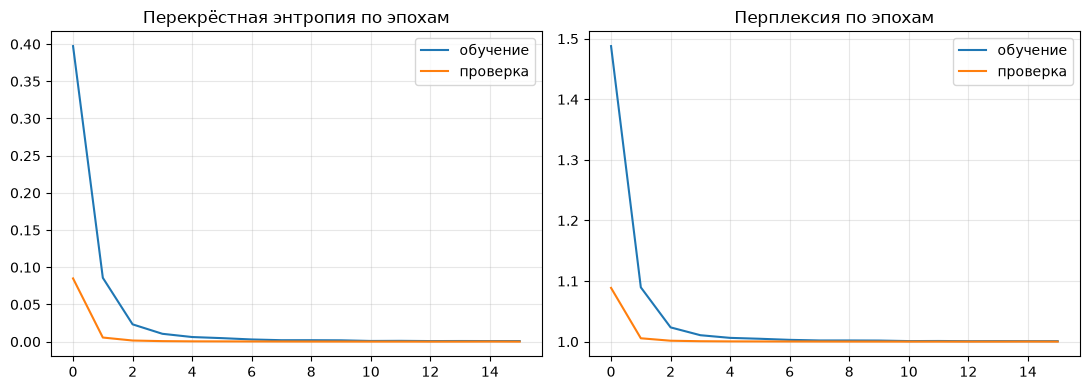

In [20]:
# Графики после TODO 4
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='обучение')
plt.plot(history.history['val_loss'], label='проверка')
plt.title('Перекрёстная энтропия по эпохам')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
train_ppl = [perplexity_from_loss(v) for v in history.history['loss']]
val_ppl = [perplexity_from_loss(v) for v in history.history['val_loss']]
plt.plot(train_ppl, label='обучение')
plt.plot(val_ppl, label='проверка')
plt.title('Перплексия по эпохам')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


In [21]:
# Контроль порогов после TODO 4
test_loss, test_token_acc = model.evaluate(X_test, y_test, verbose=0)
test_perplexity = perplexity_from_loss(test_loss)
print(f'test_loss            : {test_loss:.4f}')
print(f'test_token_accuracy  : {test_token_acc:.4f}')
print(f'test_perplexity      : {test_perplexity:.4f}')
assert test_token_acc >= 0.97, 'Токенная точность ниже порога 0.97.'
assert test_perplexity <= 1.30, 'Перплексия выше порога 1.30.'


test_loss            : 0.0001
test_token_accuracy  : 1.0000
test_perplexity      : 1.0001


## TODO 5: детерминированная генерация


In [22]:
def generate_greedy(model, prompt_ids, max_new_tokens, max_seq_len=MAX_SEQ_LEN - 1):
    """Генерирует продолжение в детерминированном режиме argmax.

    Аргументы:
      model: Обученная модель предсказания следующего токена.
      prompt_ids: Начальная последовательность идентификаторов токенов.
      max_new_tokens: Максимум новых шагов генерации.
      max_seq_len: Рабочая длина входа модели.

    Возвращает:
      Список идентификаторов с учётом исходной подсказки и сгенерированных токенов.

    Исключения:
      ValueError: Если подсказка пуста.
    """
    # TODO 5.1: Реализуйте детерминированную генерацию через argmax.
    if len(prompt_ids) == 0:
        raise ValueError('Подсказка не может быть пустой.')
    
    generated = list(prompt_ids)
    
    for _ in range(max_new_tokens):
        # Подготавливаем вход (дополняем до max_seq_len)
        input_ids = generated + [PAD_ID] * (max_seq_len - len(generated))
        input_tensor = np.array([input_ids[:max_seq_len]], dtype=np.int32)
        
        # Предсказание
        probs = model.predict(input_tensor, verbose=0)
        next_token = np.argmax(probs[0, len(generated) - 1], axis=-1)
        
        if next_token == PAD_ID or next_token == EOS_ID:
            break
        generated.append(next_token)
    
    return generated


def expected_payload_steps(prompt_ids, steps):
    """Строит эталонное продолжение по детерминированному правилу второго порядка.

    Аргументы:
      prompt_ids: Начальная последовательность токенов вида `[BOS, t1, t2, ...]`.
      steps: Сколько новых токенов нужно построить.

    Возвращает:
      Список из `steps` токенов эталонного продолжения.

    Исключения:
      ValueError: Если полезная часть подсказки короче двух токенов.
    """
    payload = [token for token in prompt_ids if token in (TOKEN_A, TOKEN_B, TOKEN_C, TOKEN_D)]
    if len(payload) < 2:
        raise ValueError('Для эталонного продолжения нужно минимум два полезных токена.')

    generated = []
    history = list(payload)
    for _ in range(steps):
        next_token = next_payload_token(history[-2], history[-1])
        generated.append(next_token)
        history.append(next_token)
    return generated


# TODO 5.2: Запустите 20 фиксированных подсказок и проверьте порог 18/20
# по ПОЛНОМУ контролируемому продолжению длины CHECK_NEW_TOKENS.
success_count = 0
total_checks = 20

for seed_offset in range(total_checks):
    rng = np.random.default_rng(SEED + seed_offset)
    start_idx = rng.integers(0, len(START_PAIRS))
    prompt_payload = START_PAIRS[start_idx].tolist()
    prompt = [BOS_ID] + prompt_payload
    
    expected = expected_payload_steps(prompt, CHECK_NEW_TOKENS)
    
    generated_full = generate_greedy(model, prompt, CHECK_NEW_TOKENS)
    generated_tokens = generated_full[len(prompt):]
    
    if generated_tokens == expected:
        success_count += 1

print(f"Успешных генераций: {success_count}/{total_checks}")
assert success_count >= 18, f"Слишком низкое качество: {success_count}/20"
print("Порог генерации пройден!")


Успешных генераций: 20/20
Порог генерации пройден!


## TODO 6: диагностика внимания


Доля внимания к будущим позициям: 0.000000
Причинная маска работает корректно!


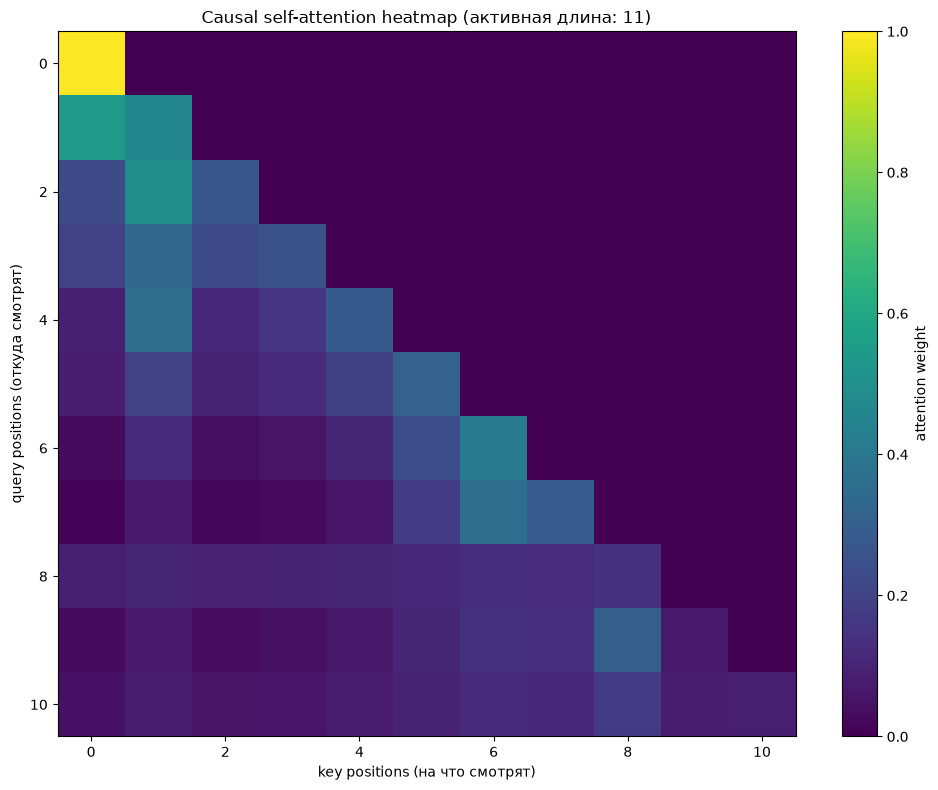

In [26]:
# TODO 6.1: Соберите tracing-path, который возвращает attention_scores из CausalDecoderBlock.
seq_len = MAX_SEQ_LEN - 1

trace_inputs = keras.Input(shape=(seq_len,), dtype='int32', name='trace_tokens')

# Используем Lambda слой (как в основной модели)
trace_padding_mask = layers.Lambda(
    lambda x: tf.cast(tf.not_equal(x, PAD_ID), tf.bool),
    name='trace_padding_mask'
)(trace_inputs)

trace_embeddings = embedding_layer(trace_inputs)
_, trace_attention = decoder_block(trace_embeddings, padding_mask=trace_padding_mask, return_attention_scores=True)

trace_model = keras.Model(inputs=trace_inputs, outputs=trace_attention)

# TODO 6.2: Усредните attention_scores по головам и обрежьте карту до непустых токенов.
sample_idx = 0
sample_tokens = X_test[sample_idx:sample_idx + 1]
sample_attention = trace_model.predict(sample_tokens, verbose=0)

mean_attention = sample_attention[0].mean(axis=0)  

pad_positions = np.where(sample_tokens[0] == PAD_ID)[0]
if len(pad_positions) > 0:
    active_len = pad_positions[0]
else:
    active_len = seq_len

mean_attention = mean_attention[:active_len, :active_len]

# TODO 6.3: Проверьте, что отношение массы внимания в будущем меньше 1e-4.
future_mask = np.triu(np.ones((active_len, active_len)), k=1).astype(bool)
future_attention = mean_attention[future_mask].sum()
total_attention = mean_attention.sum()
future_ratio = future_attention / total_attention

print(f"Доля внимания к будущим позициям: {future_ratio:.6f}")
assert future_ratio < 1e-4, "Обнаружен доступ к будущим позициям!"
print("Причинная маска работает корректно!")

# Визуализация
plt.figure(figsize=(10, 8))
plt.imshow(mean_attention, cmap='viridis', aspect='auto')
plt.colorbar(label='attention weight')
plt.xlabel('key positions (на что смотрят)')
plt.ylabel('query positions (откуда смотрят)')
plt.title(f'Causal self-attention heatmap (активная длина: {active_len})')
plt.tight_layout()
plt.show()


## Чек-лист перед завершением
1. Все `TODO` закрыты.
2. Воспроизводимость данных подтверждена на первых `k` примерах.
3. Токенная точность и перплексия проходят пороги.
4. Детерминированная генерация выполняет порог `18/20`.
5. Карта внимания не содержит доступа к будущим позициям.
